# Spatial Data Exploration (H3 Visualization)

Sourced POI Data from https://overpass-turbo.eu/ using the following Script:

```
// All POIs (nodes with tags) in Chicago

[out:json][timeout:60];
area["name"="Chicago"]->.searchArea;
(
  node(area.searchArea)[amenity];
  node(area.searchArea)[tourism];
  node(area.searchArea)[shop];
  node(area.searchArea)[leisure];
  node(area.searchArea)[office];
  node(area.searchArea)[healthcare];
  node(area.searchArea)[historic];
  node(area.searchArea)[man_made];
  node(area.searchArea)[natural];
  node(area.searchArea)[craft];
  node(area.searchArea)[sport];
  node(area.searchArea)[place];
  node(area.searchArea)[railway];
  node(area.searchArea)[public_transport];
  node(area.searchArea)[aeroway];
  node(area.searchArea)[emergency];
);
out center;
```

Then downloaded data as .geojson file. Saved data can be found in "../data/poi_chicago.geojson"

---

Sourced city boundary data from https://data.cityofchicago.org/Facilities-Geographic-Boundaries/Boundaries-City-Map/ewy2-6yfk

Downloaded data as .geojson file. Saved data can be found in "../data/chicago_boundaries.geojson"

# Imports

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import h3
import json
import pandas as pd
from shapely.geometry import shape
H3_HEXAGON_RESOLUTION = 7
BOUNDARIES_DATA_PATH = '../data/chicago_boundaries.geojson'
POI_DATA_PATH = '../data/poi_chicago.geojson'
TAXI_DATA_PATH = '../data/chicago_taxi_2025_clean.parquet'

### City boundaries

<Axes: >

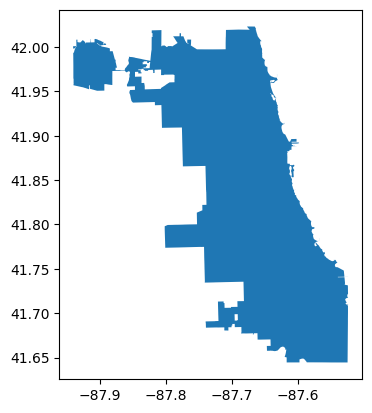

In [2]:
city = gpd.read_file(BOUNDARIES_DATA_PATH)
city_geo = city.geometry
city_geo.plot()

In [3]:
city_bounding_box_json_string = city_geo.to_json()
city_bounding_box_json = json.loads(city_bounding_box_json_string)
city_bounding_box_poly = city_bounding_box_json["features"][0]

# Computing hexagons for a given polygon
polygon_obj = city_bounding_box_poly["geometry"] # your geo json object
hexagons = h3.geo_to_cells(polygon_obj, res = H3_HEXAGON_RESOLUTION)

# Returns only the index of each hexagon, not the geometries
hexagons[:3]

['872664cd3ffffff', '872664cc3ffffff', '872664c10ffffff']

<Axes: >

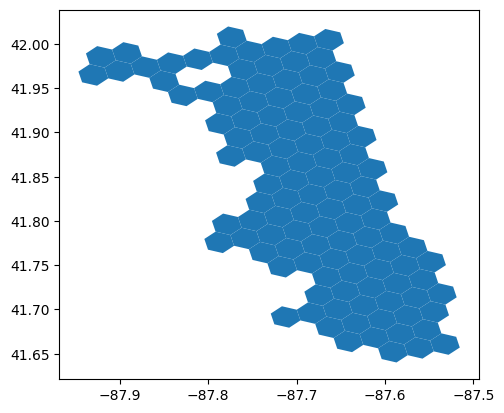

In [4]:
# Convert H3 Indexes to Geometry Objects
# Create geo data frame
df_boundaries = gpd.GeoDataFrame(list(hexagons), columns=['h3_hex_id'])

df_boundaries['h3_hex_geo'] = df_boundaries[(df_boundaries['h3_hex_id'].notna())].apply(lambda row: shape(h3.cells_to_geo([row["h3_hex_id"]])), axis=1)
df_boundaries = df_boundaries.set_geometry('h3_hex_geo')
df_boundaries.plot()

### POI Data

In [5]:
gdf_poi = gpd.read_file(POI_DATA_PATH)

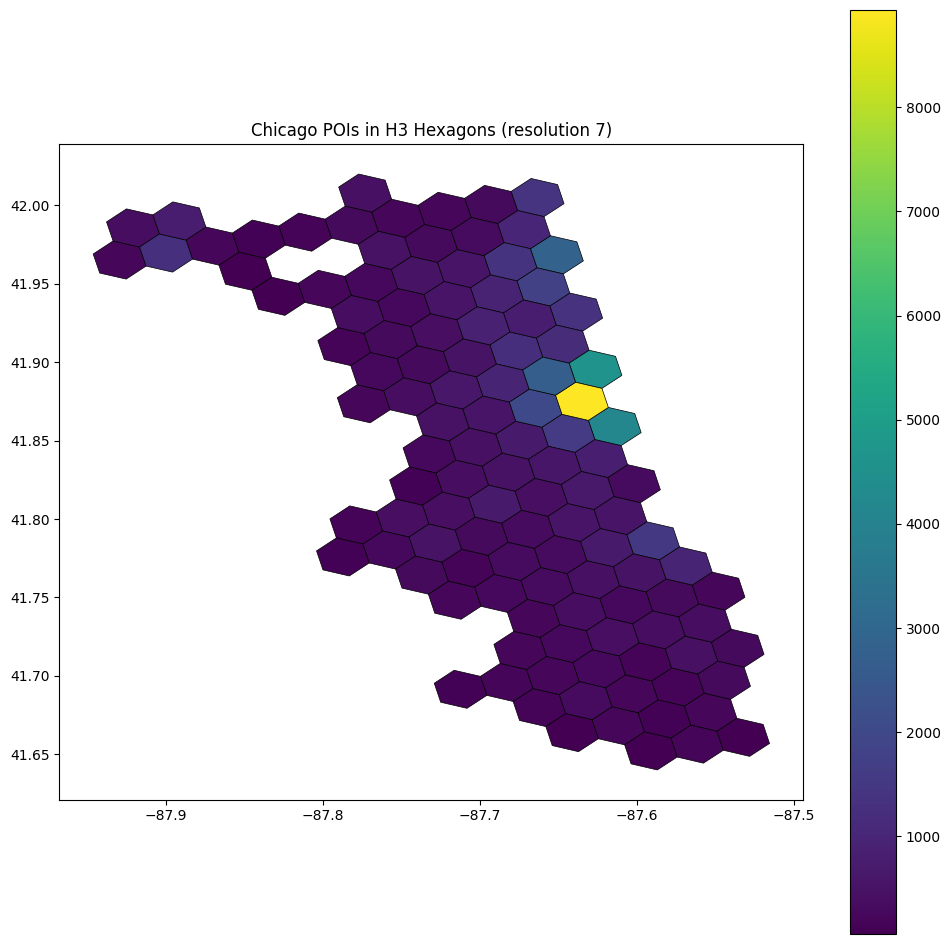

In [6]:
# Filter to points within city bounds
gdf_filtered = gdf_poi.cx[city_geo.total_bounds[0]:city_geo.total_bounds[2], 
                       city_geo.total_bounds[1]:city_geo.total_bounds[3]]

# Count POIs per hexagon using the pre-existing hexagon grid
gdf_filtered['h3_hex_id'] = [h3.latlng_to_cell(lat, lon, H3_HEXAGON_RESOLUTION) 
                              for lat, lon in zip(gdf_filtered.geometry.y, gdf_filtered.geometry.x)]

# Count POIs per hexagon
poi_counts = gdf_filtered.groupby('h3_hex_id').size().reset_index(name='count')

# Merge counts with the pre-existing hexagon geometries
coords_poi_geo = df_boundaries.merge(poi_counts, left_on='h3_hex_id', right_on='h3_hex_id', how='left')
coords_poi_geo['count'] = coords_poi_geo['count'].fillna(0)

# Now plot
fig, ax = plt.subplots(figsize=(12, 12))

coords_poi_geo.plot(
    ax=ax,
    column="count",
    cmap="viridis",
    legend=True,
    edgecolor="black",
    linewidth=0.5
)

plt.title("Chicago POIs in H3 Hexagons (resolution {})".format(H3_HEXAGON_RESOLUTION))
plt.show()

### Sort POIs by type

In [7]:
filter_list = ['amenity', 'tourism', 'shop', 'leisure',
               'office', 'healthcare', 'historic', 'man_made',
               'natural', 'craft', 'sport', 'place', 'railway',
               'public_transport', 'aeroway', 'emergency']


filtered = {}

for col in filter_list:
    filtered[col] = gdf_filtered[gdf_filtered[col].notna()]
    
for key, value in filtered.items():
    print(f"{key}: {len(value)}")

amenity: 16445
tourism: 1038
shop: 4042
leisure: 709
office: 713
healthcare: 557
historic: 366
man_made: 5479
natural: 26531
craft: 112
sport: 147
place: 282
railway: 9352
public_transport: 16333
aeroway: 1045
emergency: 470


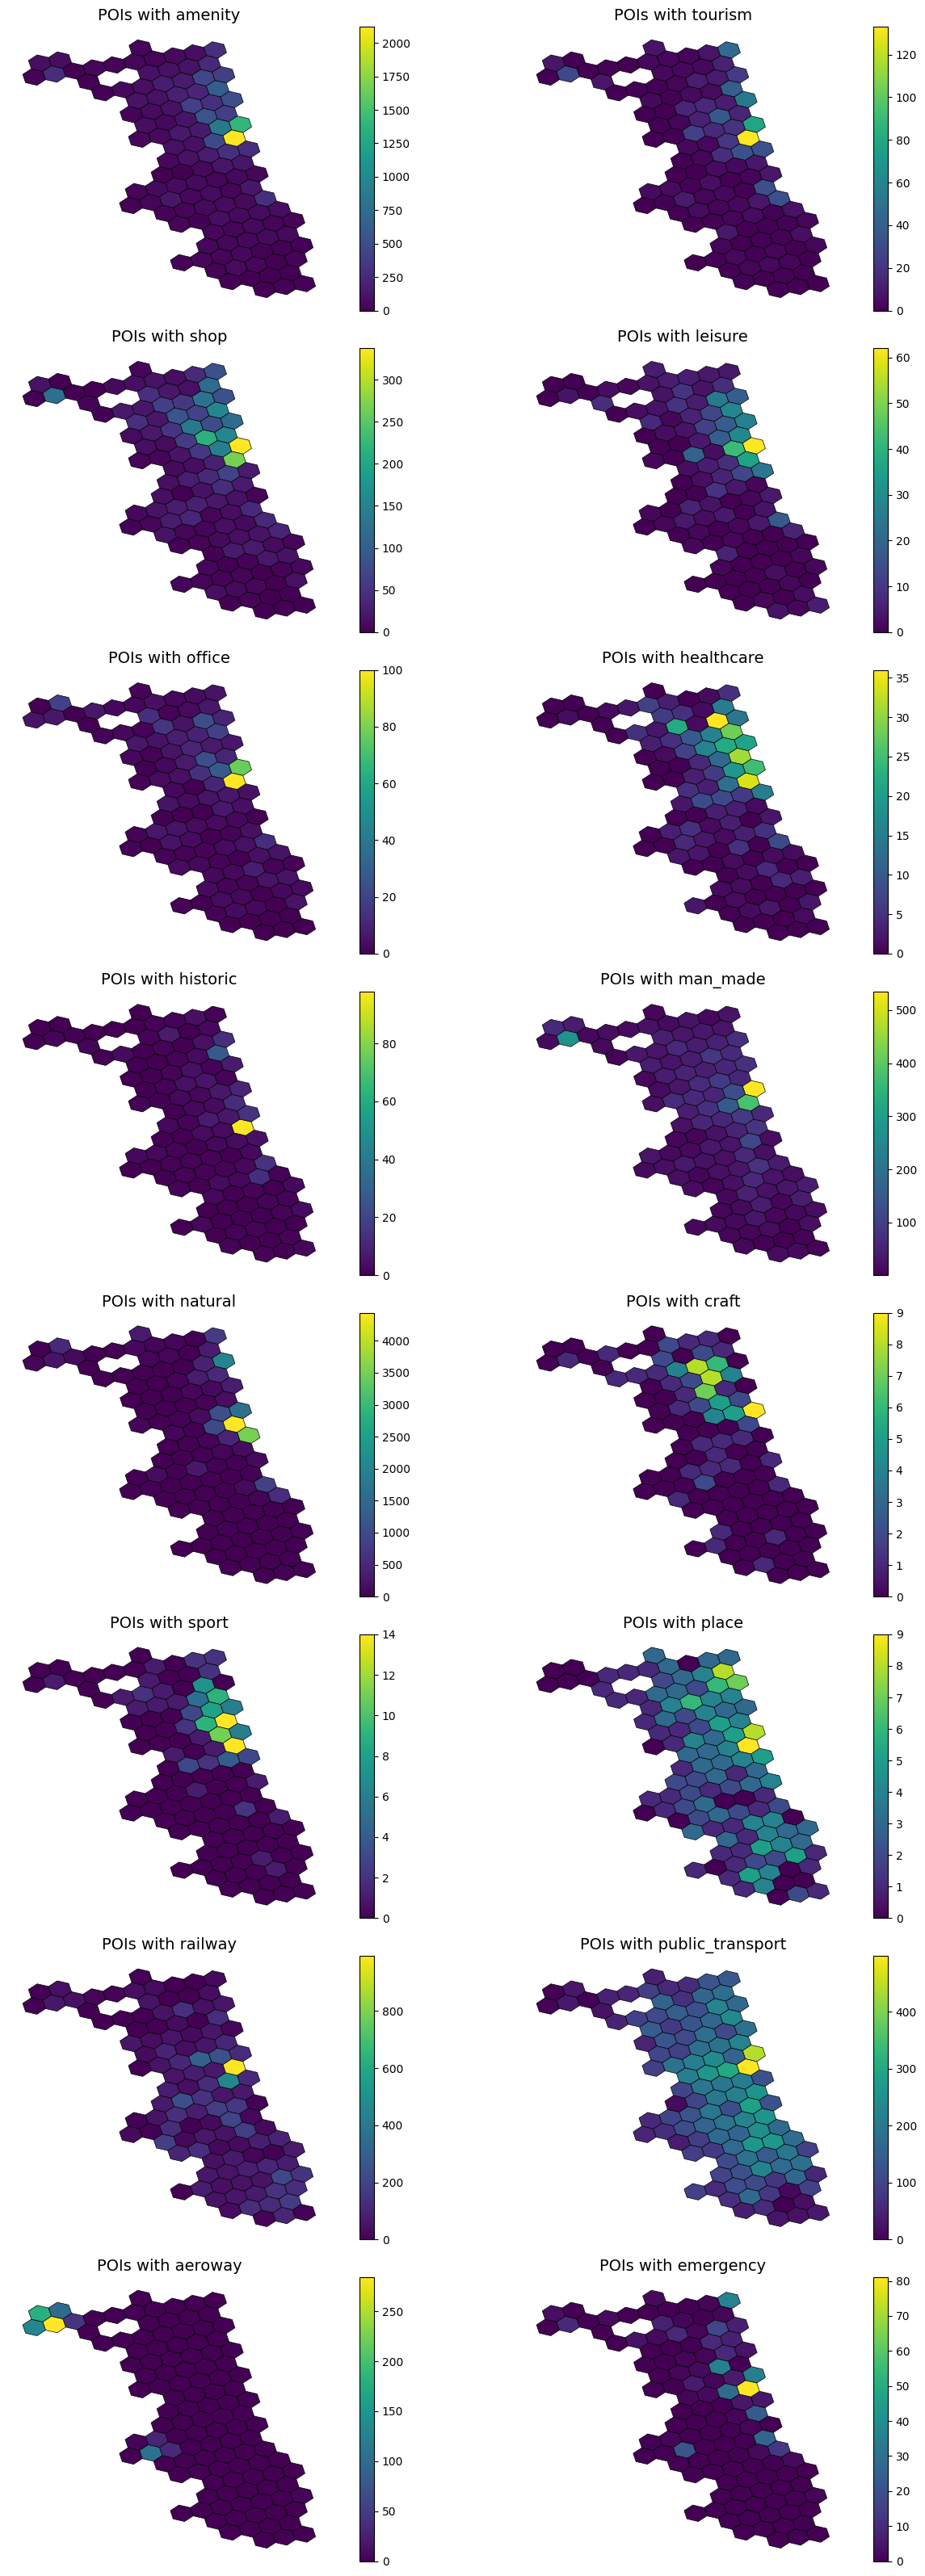

In [8]:

n_plots = len(filtered)
n_cols = 2
n_rows = 8

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 32))
axes = axes.flatten()

hex_data_list = []

# First pass: prepare data
for key, value in filtered.items():
    value_copy = value.copy()
    value_copy['h3_hex_id'] = [h3.latlng_to_cell(lat, lon, H3_HEXAGON_RESOLUTION) 
                               for lat, lon in zip(value_copy.geometry.y, value_copy.geometry.x)]
    
    type_counts = value_copy.groupby('h3_hex_id').size().reset_index(name='count')
    hex_data = df_boundaries.merge(type_counts, left_on='h3_hex_id', right_on='h3_hex_id', how='left')
    hex_data['count'] = hex_data['count'].fillna(0)
    hex_data_list.append(hex_data)

# Second pass: plot with individual color scales
for i, (key, hex_data) in enumerate(zip(filtered.keys(), hex_data_list)):
    ax = axes[i]
    hex_data.plot(ax=ax, column='count', cmap='viridis', legend=True, 
                  edgecolor='black', linewidth=0.5)
    ax.set_title(f"POIs with {key}", fontsize=14)
    ax.axis('off')

# Hide unused subplots
for j in range(len(filtered), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### Taxi Trip data

In [9]:
taxi_data = pd.read_parquet(TAXI_DATA_PATH)
taxi_data.head()

,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,payment_type,company,pickup_centroid_latitude,pickup_centroid_longitude,dropoff_centroid_latitude,dropoff_centroid_longitude,pickup_ca_centroid_lat,pickup_ca_centroid_lon,dropoff_ca_centroid_lat,dropoff_ca_centroid_lon
0,0826d395e39c5ea146c37c8a78a03c012986b167,b89de8fefce2927a1bbc747ac861743fc5482ed36590d2...,2025-01-07 23:45:00,2025-01-08 00:00:00,1405.0,14.84,NaN,NaN,76,6,...,Credit Card,Taxicab Insurance Agency Llc,41.980264,-87.913625,41.944227,-87.655998,41.980264,-87.913625,41.944227,-87.655998
1,f7249eff1aad5ea1b3d53539a4003f3348786b27,60d596d3448473e61c35fc30a37bf8fda28d4ae7fa3bea...,2025-01-07 23:45:00,2025-01-08 00:00:00,318.0,1.30,NaN,NaN,8,8,...,Cash,Flash Cab,41.899602,-87.633308,41.899602,-87.633308,41.899602,-87.633308,41.899602,-87.633308
2,e7f005ad347a0f7f699523fc7843ba5f8b8792c1,0b0be23bf69b80dd81715f86c4e0887bbd5d9ebc2463b8...,2025-01-07 23:45:00,2025-01-07 23:45:00,419.0,0.87,NaN,NaN,8,8,...,Credit Card,Blue Ribbon Taxi Association,41.899602,-87.633308,41.899602,-87.633308,41.899602,-87.633308,41.899602,-87.633308
3,e6df7890fb2d74e09132af5cde612ea36ff5360d,488f74778b200fa256453e785aceb902249139d4880bc1...,2025-01-07 23:45:00,2025-01-08 00:00:00,1272.0,14.37,NaN,NaN,76,22,...,Credit Card,Chicago Taxicab,41.980264,-87.913625,41.922761,-87.699155,41.980264,-87.913625,41.922761,-87.699155
4,d5f005f6e423e808546dd1419fee4f2dafc55872,b9a58663518c48b09e83f462ca25ee0d702a2e4bc12199...,2025-01-07 23:45:00,2025-01-08 00:00:00,1368.0,17.25,NaN,NaN,76,28,...,Credit Card,City Service,41.980264,-87.913625,41.874005,-87.663518,41.980264,-87.913625,41.874005,-87.663518


In [10]:
taxi_data.count()

trip_id                       5652351
taxi_id                       5652345
trip_start_timestamp          5652351
trip_end_timestamp            5652351
trip_seconds                  5652351
trip_miles                    5652351
pickup_census_tract           2662107
dropoff_census_tract          2662107
pickup_community_area         5652351
dropoff_community_area        5652351
fare                          5652351
tips                          5652351
tolls                         5652351
extras                        5652351
trip_total                    5652351
payment_type                  5652351
company                       5652351
pickup_centroid_latitude      5652351
pickup_centroid_longitude     5652351
dropoff_centroid_latitude     5652351
dropoff_centroid_longitude    5652351
pickup_ca_centroid_lat        5652351
pickup_ca_centroid_lon        5652351
dropoff_ca_centroid_lat       5652351
dropoff_ca_centroid_lon       5652351
dtype: int64

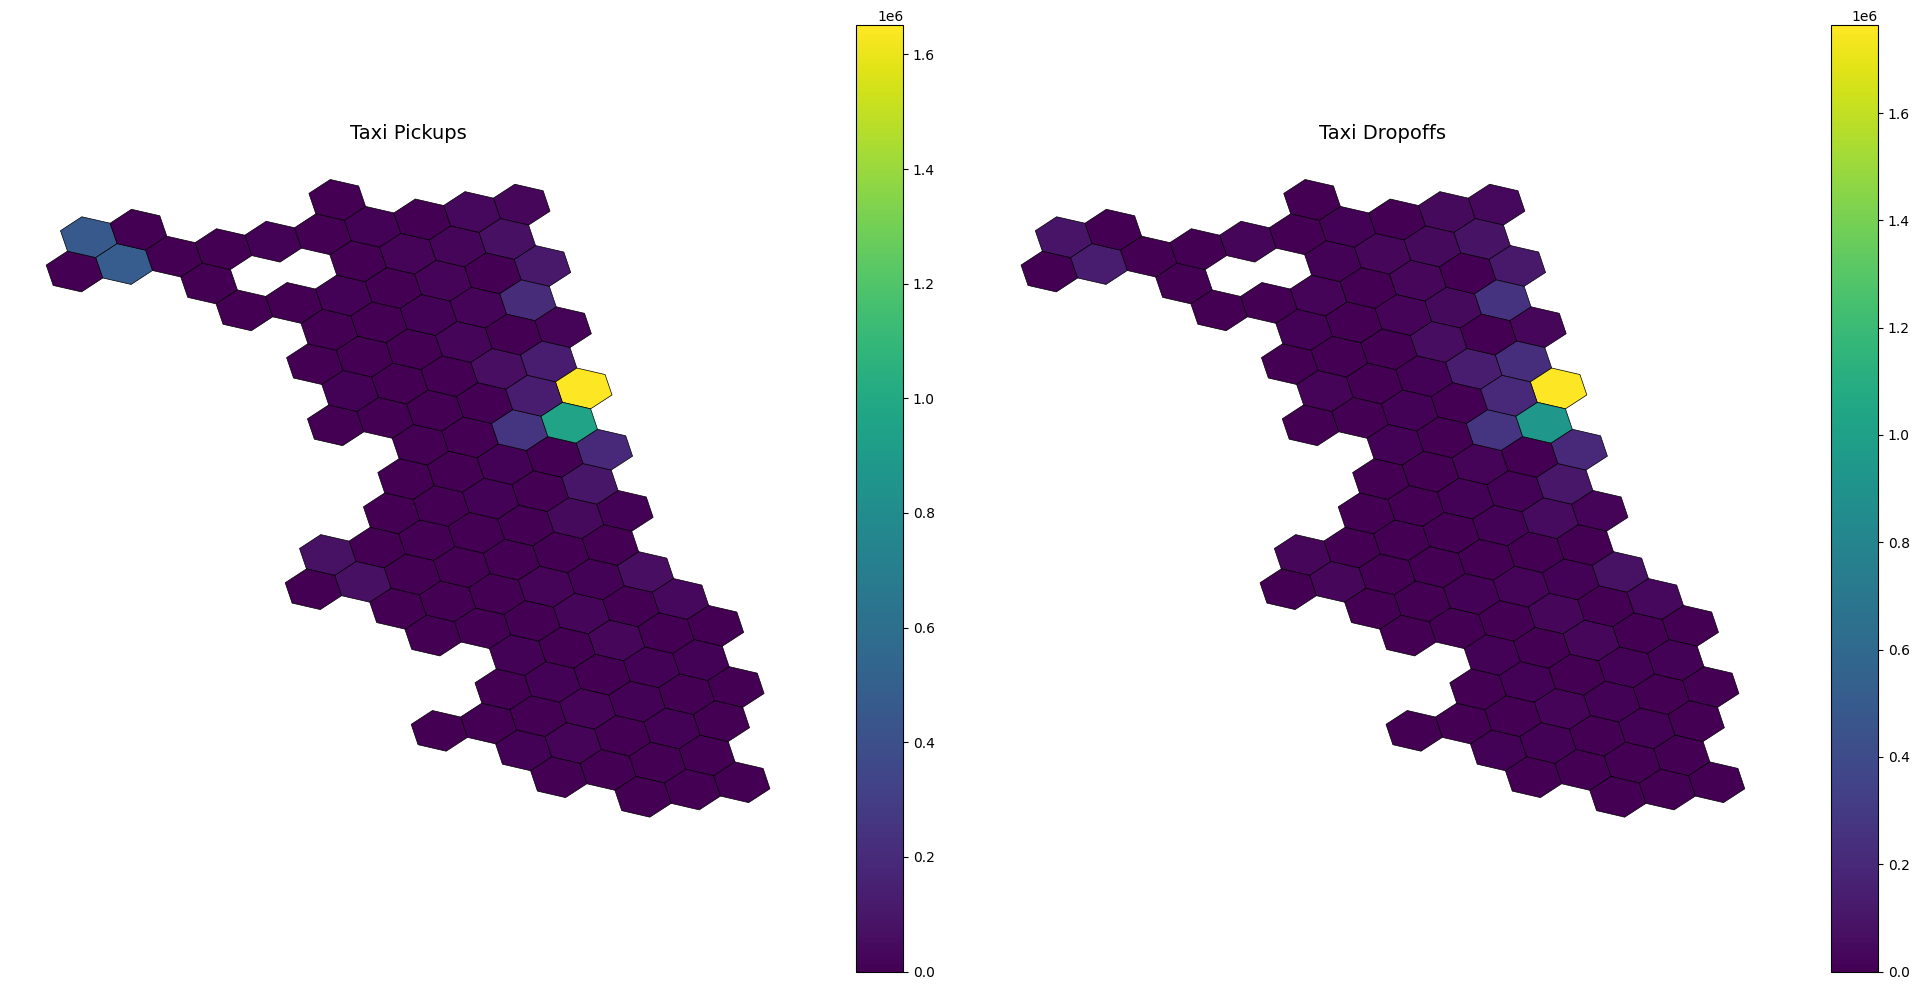

Pickups: 5652351
Dropoffs: 5652351


In [11]:
# Create GeoDataFrame for pickups and dropoffs
pickups_gdf = gpd.GeoDataFrame(
    taxi_data,
    geometry=gpd.points_from_xy(taxi_data['pickup_centroid_longitude'], taxi_data['pickup_centroid_latitude']),
    crs='EPSG:4326'
)

dropoffs_gdf = gpd.GeoDataFrame(
    taxi_data,
    geometry=gpd.points_from_xy(taxi_data['dropoff_centroid_longitude'], taxi_data['dropoff_centroid_latitude']),
    crs='EPSG:4326'
)

# Filter to city bounds
pickups_filtered = pickups_gdf.cx[city_geo.total_bounds[0]:city_geo.total_bounds[2], 
                                   city_geo.total_bounds[1]:city_geo.total_bounds[3]]
dropoffs_filtered = dropoffs_gdf.cx[city_geo.total_bounds[0]:city_geo.total_bounds[2], 
                                     city_geo.total_bounds[1]:city_geo.total_bounds[3]]

# Assign h3 cells
pickups_filtered['h3_hex_id'] = [h3.latlng_to_cell(lat, lon, H3_HEXAGON_RESOLUTION) 
                                  for lat, lon in zip(pickups_filtered.geometry.y, pickups_filtered.geometry.x)]
dropoffs_filtered['h3_hex_id'] = [h3.latlng_to_cell(lat, lon, H3_HEXAGON_RESOLUTION) 
                                   for lat, lon in zip(dropoffs_filtered.geometry.y, dropoffs_filtered.geometry.x)]

# Count per hexagon
pickups_counts = pickups_filtered.groupby('h3_hex_id').size().reset_index(name='count')
dropoffs_counts = dropoffs_filtered.groupby('h3_hex_id').size().reset_index(name='count')

# Merge with hexagon geometries
pickups_hex = df_boundaries.merge(pickups_counts, left_on='h3_hex_id', right_on='h3_hex_id', how='left')
pickups_hex['count'] = pickups_hex['count'].fillna(0)

dropoffs_hex = df_boundaries.merge(dropoffs_counts, left_on='h3_hex_id', right_on='h3_hex_id', how='left')
dropoffs_hex['count'] = dropoffs_hex['count'].fillna(0)

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

pickups_hex.plot(ax=axes[0], column='count', cmap='viridis', legend=True, 
                 edgecolor='black', linewidth=0.5)
axes[0].set_title('Taxi Pickups', fontsize=14)
axes[0].axis('off')

dropoffs_hex.plot(ax=axes[1], column='count', cmap='viridis', legend=True, 
                  edgecolor='black', linewidth=0.5)
axes[1].set_title('Taxi Dropoffs', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Pickups: {len(pickups_filtered)}")
print(f"Dropoffs: {len(dropoffs_filtered)}")